In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import itertools
import math
from scipy.stats import pearsonr

In [3]:
# load the Excel file with the different solutions of Pareto front and Pareto set
filename = 'GAA_MOO.xls'

df = pd.read_excel(filename, sheet_name=0, header=0)

df['$RANGE [10^{3}nmi]$'] *= -1.0
df['$LDMAX [Ratio]$'] *= -1.0
df['$VCMAX [knots]$'] *= -1.0
df.head()

,ALGORITHM,$NOISE [dB]$,$WEMP [10^{3}lb]$,$DOC [USD/hr]$,$ROUGH [Ratio]$,$WFUEL [10^{2}lb]$,$PURCH [10^{3}USD]$,$RANGE [10^{3}nmi]$,$LDMAX [Ratio]$,$VCMAX [knots]$,...,TAPER4,CSPD6,AR6,SWEEP6,DPROP6,WINGLD6,AF6,SEATW6,ELODT6,TAPER6
0,2,73.849038,1.950129,59.781232,1.888365,4.262706,43.549604,2.029819,14.876334,196.393386,...,0.475269,0.240238,7.591070,5.611444,5.625784,23.626033,85.256005,18.459719,3.744443,0.481571
1,2,73.285267,1.953214,79.805768,1.930696,4.252236,43.290384,2.328814,15.302294,191.772425,...,0.498979,0.314680,7.079204,3.022159,5.500045,21.832243,87.637879,18.671505,3.661989,0.496724
2,2,73.634287,1.960262,62.401509,1.904507,4.194810,43.599497,2.124064,14.852269,193.481654,...,0.471815,0.244045,7.158738,4.410826,5.607004,22.643965,90.458060,18.980970,3.712806,0.481555
3,2,73.343767,1.972822,77.127543,1.962998,4.038559,43.714067,2.206617,15.604315,192.105663,...,0.485129,0.286624,7.678927,0.089579,5.513992,21.987356,86.437621,18.959736,3.746625,0.503160
4,2,73.332009,1.909893,62.622987,1.859312,4.486764,42.738621,2.107122,14.896494,197.746359,...,0.460694,0.240011,7.177425,5.913802,5.502678,24.088620,85.252496,17.263060,3.715281,0.475568


In [4]:
df.keys()

Index(['ALGORITHM', '$NOISE [dB]$', '$WEMP [10^{3}lb]$', '$DOC [USD/hr]$',
       '$ROUGH [Ratio]$', '$WFUEL [10^{2}lb]$', '$PURCH [10^{3}USD]$',
       '$RANGE [10^{3}nmi]$', '$LDMAX [Ratio]$', '$VCMAX [knots]$',
       '$PFPF [Ratio]$', 'CSPD2', 'AR2', 'SWEEP2', 'DPROP2', 'WINGLD2', 'AF2',
       'SEATW2', 'ELODT2', 'TAPER2', 'CSPD4', 'AR4', 'SWEEP4', 'DPROP4',
       'WINGLD4', 'AF4', 'SEATW4', 'ELODT4', 'TAPER4', 'CSPD6', 'AR6',
       'SWEEP6', 'DPROP6', 'WINGLD6', 'AF6', 'SEATW6', 'ELODT6', 'TAPER6'],
      dtype='object')

In [5]:
def tradeoff_index(XX, ncolor=8, out_clr=None, OFnames=None):
    """
    Python translation of MATLAB function tradeoff_index

    Parameters
    ----------
    XX : ndarray (nsols, nobj)
        Objective values
    ncolor : int
        Number of colors
    out_clr : ndarray or None
        Color palette
    OFnames : list of str or None
        Objective names

    Returns
    -------
    hh : matplotlib.figure.Figure
        Figure handle
    lambdas : ndarray
        Lambda matrices (nrows, nrows, ntradeoffs)
    to_names : list
        Trade-off names
    """

    XX = np.asarray(XX, dtype=float)
    nsols, nobj = XX.shape

    # Objective names
    if OFnames is None or len(OFnames) == 0:
        OFnames = [f"obj{i+1}" for i in range(nobj)]

    # Plot options
    #sel_fontname = "Times"
    sel_fontsize = 6
    sel_fontweight = "normal"
    ndecimals = 3
    strformat = f"%.{ndecimals}f"

    # Rescale objectives to [0,1]
    XX2 = (XX - XX.min(axis=0)) / (XX.max(axis=0) - XX.min(axis=0))

    ntradeoffs = math.comb(nobj, 2)
    nrows = int(np.ceil(np.sqrt(nsols)))
    print(nrows)
    
    lambdas = np.zeros((nrows, nrows, ntradeoffs))

    # Correlations
    rhoes = np.zeros((nobj, nobj))
    pvals = np.zeros((nobj, nobj))
    for i in range(nobj):
        for j in range(nobj):
            rhoes[i, j], pvals[i, j] = pearsonr(XX2[:, i], XX2[:, j])

    # ---- Tradeoff Index estimation ----
    to_names = []
    ito = 0

    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            L = np.zeros(nrows * nrows)

            for si in range(nsols):
                beta = np.zeros(nsols)
                for sj in range(nsols):
                    if si != sj:
                        xp = (XX2[si, of1] - XX2[sj, of1]) * \
                             (XX2[si, of2] - XX2[sj, of2])
                        if xp < 0:
                            beta[sj] = 1.0
                L[si] = np.sum(beta) / (nsols - 1)

            lambdas[:, :, ito - 1] = L.reshape((nrows, nrows)).T

            percentage = (np.sum(L) / nsols) * 100
            label = [
                #f"{OFnames[of1]} -> {OFnames[of2]}",
                f"$\\lambda$:{percentage:3.1f}",
                f"$r = {rhoes[of1, of2]:1.3f}$"
            ]
            
            to_names.append(label)

    # ---- Plotting ----
    hh = plt.figure(figsize=(10.1, 9.1), facecolor="white")
    ax = plt.gca()

    xfalse = (np.arange(nrows) + 0.5) / nrows
    text_size = 18 - nobj
    ito = 0
    
    # Colormap
    if out_clr is None:
        out_clr = create_colors(ncolor)

    cmap = plt.colormaps['RdBu_r']#, ncolor)
    
    #plt.clim(0, 1)
    
    for of1 in range(nobj - 1):
        for of2 in range(of1 + 1, nobj):
            ito += 1
            xp = (of2 - 1) + xfalse
            yp = (nobj - (of1 + 2)) + xfalse
            

            X, Y = np.meshgrid(xp, yp)
            Z = lambdas[:, :, ito - 1]
            ax.pcolormesh(X, Y, Z, shading="nearest", cmap=cmap)

            ax.text(
                np.mean(xp), np.mean(yp),
                "\n".join(to_names[ito - 1]),
                ha = "center", 
                va = "center",
                fontsize   = text_size, #fontname=sel_fontname,
                fontweight = sel_fontweight,
                bbox       = dict(facecolor="white", edgecolor="black")
            )
            #ax.cmap(cmap)
    # Frame
    ax.plot([0, nobj-1, nobj-1, 0, 0],
            [0, 0, nobj-1, nobj-1, 0],
            "k-", linewidth = 0.5)

    #ax.set_xlim(0, nobj - 1)
    #ax.set_ylim(0, nobj - 1)
    ax.set_xticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_yticks(np.arange(0,nobj-1)+0.5)#[0, nobj-1])
    ax.set_xticklabels(OFnames[1:])#['', ''])
    ax.set_yticklabels(OFnames[::-1][1:])#['', ''])
    ax.set_aspect("equal")

    ax.set_title(
        "Trade-off Index $\\lambda$ [%]", #fontname=sel_fontname,
        fontsize=sel_fontsize + 6,
        fontweight="bold"
    )

    #ax.colorbar()

    #cbar = plt.colorbar(
    #    ticks=np.linspace(0, 1, ncolor + 1),
    #    fraction=0.046, pad=0.04
    #)
    #cbar.ax.set_title("$\\lambda$", fontsize=sel_fontsize + 4)

    return hh, lambdas, to_names

In [6]:
def create_colors(ncolor):
    return plt.cm.RdBu_r(np.linspace(0, 1, ncolor))

In [17]:
OFnames = ['NOISE \n [$dB$]', 'WEMP \n [$10^{3}lb$]', 'DOC \n [$USD/hr$]',
       'ROUGH \n [Ratio]', 'WFUEL \n [$10^{2}lb$]', 'PURCH \n [$10^{3}USD$]',
       'RANGE \n [$10^{3}nmi$]', 'LDMAX \n [Ratio]', 'VCMAX \n [knots]',
       'PFPF \n [Ratio]']

In [19]:
F = df[['$NOISE [dB]$', '$WEMP [10^{3}lb]$', '$DOC [USD/hr]$',
       '$ROUGH [Ratio]$', '$WFUEL [10^{2}lb]$', '$PURCH [10^{3}USD]$',
       '$RANGE [10^{3}nmi]$', '$LDMAX [Ratio]$', '$VCMAX [knots]$',
       '$PFPF [Ratio]$']].to_numpy()
F[:113**2,:].shape

(12769, 10)

114


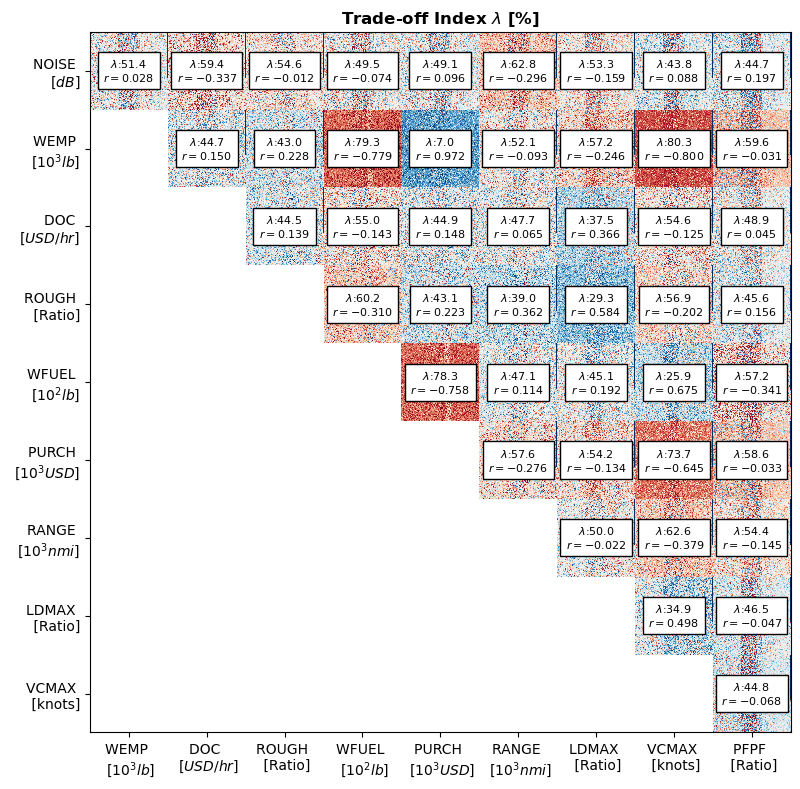

In [20]:
fig, lambdas, names = tradeoff_index(
    F[:113**2,:],
    ncolor=8,
    OFnames=OFnames,
)
plt.show()

In [14]:
113**2

12769